In [4]:
import pandas as pd
import numpy as np
import os

In [5]:
df_stack_21 = pd.read_csv("data/stack-overflow-developer-survey-2021.csv")
df_stack_21.head(10)

,ResponseId,MainBranch,Employment,Country,US_State,UK_Country,EdLevel,Age1stCode,LearnCode,YearsCode,...,Age,Gender,Trans,Sexuality,Ethnicity,Accessibility,MentalHealth,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,I am a developer by profession,"Independent contractor, freelancer, or self-em...",Slovakia,NaN,NaN,"Secondary school (e.g. American high school, G...",18 - 24 years,Coding Bootcamp;Other online resources (ex: vi...,NaN,...,25-34 years old,Man,No,Straight / Heterosexual,White or of European descent,None of the above,None of the above,Appropriate in length,Easy,62268.0
1,2,I am a student who is learning to code,"Student, full-time",Netherlands,NaN,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",11 - 17 years,"Other online resources (ex: videos, blogs, etc...",7,...,18-24 years old,Man,No,Straight / Heterosexual,White or of European descent,None of the above,None of the above,Appropriate in length,Easy,NaN
2,3,"I am not primarily a developer, but I write co...","Student, full-time",Russian Federation,NaN,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",11 - 17 years,"Other online resources (ex: videos, blogs, etc...",NaN,...,18-24 years old,Man,No,Prefer not to say,Prefer not to say,None of the above,None of the above,Appropriate in length,Easy,NaN
3,4,I am a developer by profession,Employed full-time,Austria,NaN,NaN,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",11 - 17 years,NaN,NaN,...,35-44 years old,Man,No,Straight / Heterosexual,White or of European descent,I am deaf / hard of hearing,NaN,Appropriate in length,Neither easy nor difficult,NaN
4,5,I am a developer by profession,"Independent contractor, freelancer, or self-em...",United Kingdom of Great Britain and Northern I...,NaN,England,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",5 - 10 years,Friend or family member,17,...,25-34 years old,Man,No,NaN,White or of European descent,None of the above,NaN,Appropriate in length,Easy,NaN
5,6,I am a student who is learning to code,"Student, part-time",United States of America,Georgia,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",11 - 17 years,"Other online resources (ex: videos, blogs, etc...",NaN,...,18-24 years old,Prefer not to say,No,Straight / Heterosexual,Prefer not to say,None of the above,I have a concentration and/or memory disorder ...,Too long,Neither easy nor difficult,NaN
6,7,I code primarily as a hobby,I prefer not to say,United States of America,New Hampshire,NaN,"Secondary school (e.g. American high school, G...",11 - 17 years,"Other online resources (ex: videos, blogs, etc...",3,...,Prefer not to say,Prefer not to say,No,NaN,I don't know,None of the above,None of the above,Appropriate in length,Neither easy nor difficult,NaN
7,8,I am a student who is learning to code,"Student, full-time",Malaysia,NaN,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",11 - 17 years,School;Online Courses or Certification,4,...,18-24 years old,Woman,No,Straight / Heterosexual,White or of European descent;Multiracial;South...,None of the above,None of the above,Appropriate in length,Easy,NaN
8,9,I am a developer by profession,Employed part-time,India,NaN,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",18 - 24 years,Coding Bootcamp,6,...,25-34 years old,Man,No,NaN,South Asian,NaN,I have a concentration and/or memory disorder ...,Appropriate in length,Easy,NaN
9,10,I am a developer by profession,Employed full-time,Sweden,NaN,NaN,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",11 - 17 years,School,7,...,25-34 years old,Man,No,Straight / Heterosexual,White or of European descent,None of the above,None of the above,Appropriate in length,Neither easy nor difficult,51552.0


In [6]:
df_stack_21.info()

<class 'pandas.DataFrame'>
RangeIndex: 83439 entries, 0 to 83438
Data columns (total 48 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ResponseId                    83439 non-null  int64  
 1   MainBranch                    83439 non-null  str    
 2   Employment                    83323 non-null  str    
 3   Country                       83439 non-null  str    
 4   US_State                      14920 non-null  str    
 5   UK_Country                    4418 non-null   str    
 6   EdLevel                       83126 non-null  str    
 7   Age1stCode                    83243 non-null  str    
 8   LearnCode                     82963 non-null  str    
 9   YearsCode                     81641 non-null  str    
 10  YearsCodePro                  61216 non-null  str    
 11  DevType                       66484 non-null  str    
 12  OrgSize                       60726 non-null  str    
 13  Currency    

In [7]:
# obtrener los distintos valores de la columna "MainBranch"
df_stack_21["MainBranch"].unique()

<StringArray>
[                                               'I am a developer by profession',
                                        'I am a student who is learning to code',
 'I am not primarily a developer, but I write code sometimes as part of my work',
                                                   'I code primarily as a hobby',
                      'I used to be a developer by profession, but no longer am',
                                                                 'None of these']
Length: 6, dtype: str

In [8]:
#descartamos 'I code primarily as a hobby', 'I used to be a developer... but no longer am' y 'None of these'

interesantes = [
    'I am a developer by profession',
    'I am a student who is learning to code',
    'I am not primarily a developer, but I write code sometimes as part of my work'
]

# Filtramos el DataFrame
df_stack_21_dedicacion = df_stack_21[df_stack_21['MainBranch'].isin(interesantes)]
df_stack_21_dedicacion.shape

(76760, 48)

In [9]:
df_stack_dedicacion_spain_2021 = df_stack_21_dedicacion[df_stack_21_dedicacion["Country"].values == "Spain"]
print(df_stack_dedicacion_spain_2021.shape)

(1407, 48)


In [10]:
df_stack_22 = pd.read_csv("data/stack-overflow-developer-survey-2022.csv")
df_stack_23 = pd.read_csv("data/stack-overflow-developer-survey-2023.csv")
df_stack_24 = pd.read_csv("data/stack-overflow-developer-survey-2024.csv")
df_stack_25 = pd.read_csv("data/stack-overflow-developer-survey-2025.csv")

C:\Users\jlalo\AppData\Local\Temp\ipykernel_22976\2924736885.py:4: DtypeWarning: Columns (0: JobSatPoints_15_TEXT, 1: DatabaseHaveEntry, 2: DevEnvHaveEntry, 3: SOTagsHaveEntry, 4: SOTagsWant Entry, 5: OfficeStackWantEntry, 6: CommPlatformHaveEntr, 7: CommPlatformWantEntr, 8: SO_Actions_15_TEXT, 9: AIAgentOrchestration, 10: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  df_stack_25 = pd.read_csv("data/stack-overflow-developer-survey-2025.csv")


Hacemos el mismo proceso con el resto de datasets para filtra los datos que nos interesan.

In [11]:
df_stack_25.shape

(49191, 172)

In [12]:
#hacemos el mismo proceso de filtrado sobre dedicación y país para los otros años

years = [2022, 2023, 2024, 2025]
array_dfs = [df_stack_22, df_stack_23, df_stack_24, df_stack_25]

for year, df in zip(years, array_dfs):
    df_dedicacion = df[df['MainBranch'].isin(interesantes)]
    globals()[f"df_stack_dedicacion_spain_{year}"] = df_dedicacion[df_dedicacion["Country"].values == "Spain"]

In [13]:
# Lista de columnas maestras que queremos
# Columnas que vamos a extraer de cada año (si existen)
columnas_interes = {
    'MainBranch': 'Dedicacion',
    'Country': 'Pais',
    'Age' : 'Edad',
    'YearsCodePro': 'Años_programando',
    'LanguageHaveWorkedWith': 'Lenguajes_uso',
    'LanguageWantToWorkWith': 'Lenguajes_deseo',
    'LearnCode': 'Metodo_aprendizaje',
    'LearnCodeOnline': 'Metodo_aprendizaje_online',
    'DevType': 'Categoria_Profesional',
    'ConvertedCompYearly': 'Salario_anual',
    'AISentiment': 'IA_sentimiento',
    'AIToolCurrentlyUsing': 'IA_herramientas',
    'AIAgentExternal': 'IA_herramientas_Externas' # Mapeamos la de 2025 a la genérica
}

# Al cargar cada año:
def load_and_standardize(year_file, year_label):
    df = pd.read_csv(year_file, low_memory=False)
    existing_cols = [c for c in columnas_interes.keys() if c in df.columns] # Solo nos quedamos con las columnas que existen en columnas_interes
    df = df[existing_cols].copy()
    df.rename(columns=columnas_interes, inplace=True)
    #filtramos por dedicación para reducir el tamaño del DataFrame
    df = df[df['Dedicacion'].isin(interesantes)]
    df['Year'] = year_label
    return df

def filter_by_country(df, country="Spain"):
    return df[df['Pais'].values == country]

years = [2021, 2022, 2023, 2024, 2025]
dfs = [load_and_standardize(f"data/stack-overflow-developer-survey-{y}.csv", y) for y in years]

df_master_total = pd.concat(dfs, axis=0, ignore_index=True)
df_master = filter_by_country(df_master_total, "Spain")


In [14]:
print(f"totales: {df_master_total.shape}")
print(f"filtrados por país: {df_master.shape}")

totales: (290972, 12)
filtrados por país: (5751, 12)


In [15]:
df_master.head(10)

,Dedicacion,Pais,Edad,Años_programando,Lenguajes_uso,Lenguajes_deseo,Metodo_aprendizaje,Categoria_Profesional,Salario_anual,Year,Metodo_aprendizaje_online,IA_herramientas_Externas
10,I am a developer by profession,Spain,25-34 years old,5,Bash/Shell;HTML/CSS;JavaScript;Node.js;SQL;Typ...,C++;Clojure;JavaScript;Node.js;Rust;SQL;TypeSc...,"Other online resources (ex: videos, blogs, etc...","Developer, back-end",46482.0,2021,NaN,NaN
59,I am a developer by profession,Spain,35-44 years old,10,Bash/Shell;JavaScript;Node.js;TypeScript,JavaScript;Node.js;Python;TypeScript,School,"Developer, back-end",58373.0,2021,NaN,NaN
70,I am a developer by profession,Spain,18-24 years old,NaN,C#;Go;Java;Python,C++;Clojure;Go;Rust,Online Courses or Certification,"Developer, back-end",21620.0,2021,NaN,NaN
98,I am a developer by profession,Spain,25-34 years old,8,HTML/CSS;Java;JavaScript;Node.js;Python;SQL,HTML/CSS;Java;JavaScript;Node.js;Python;SQL;Ty...,Coding Bootcamp;School,"Developer, full-stack;Developer, back-end;Prod...",38915.0,2021,NaN,NaN
242,I am a developer by profession,Spain,35-44 years old,13,HTML/CSS;Java;JavaScript;Node.js;SQL,HTML/CSS;Java;JavaScript;Node.js;Python;SQL,Other (please specify):,"Developer, full-stack",NaN,2021,NaN,NaN
244,I am a developer by profession,Spain,25-34 years old,4,Bash/Shell;C;C++;HTML/CSS;Java;JavaScript;Node...,Bash/Shell;HTML/CSS;Java;JavaScript;Node.js;PH...,Online Forum,"Developer, back-end;Academic researcher;Databa...",NaN,2021,NaN,NaN
270,I am a developer by profession,Spain,25-34 years old,5,Kotlin;Python,Kotlin;Python,"Other online resources (ex: videos, blogs, etc...","Developer, mobile;Developer, front-end;Develop...",32429.0,2021,NaN,NaN
271,I am a developer by profession,Spain,25-34 years old,10,Assembly;Bash/Shell;C;C#;C++;Go;HTML/CSS;Java;...,Bash/Shell;C#;C++;Crystal;Dart;Delphi;Elixir;E...,Coding Bootcamp;Other online resources (ex: vi...,Other (please specify):,12972.0,2021,NaN,NaN
274,I am a developer by profession,Spain,25-34 years old,4,C#;JavaScript;Kotlin;TypeScript,C#;JavaScript;Kotlin;SQL;TypeScript,"Other online resources (ex: videos, blogs, etc...","Developer, full-stack",28105.0,2021,NaN,NaN
350,I am a developer by profession,Spain,25-34 years old,10,Bash/Shell;JavaScript;Python;SQL,C++,Coding Bootcamp;Other online resources (ex: vi...,"Developer, full-stack;Developer, back-end",64860.0,2021,NaN,NaN


In [16]:
# creamos una lista de los lenguajes usados y deseados
languages_usados = df_master['Lenguajes_uso'].dropna().str.split(';').explode().unique()
languages_deseados = df_master['Lenguajes_deseo'].dropna().str.split(';').explode().unique()
total_languages = set(languages_usados) | set(languages_deseados)

In [17]:
#guardamos en un diccionario los lenguajes más populares contando las veces en salen en los lenguajes usados y deseados
used_languages = {}
desired_languages = {}
popular_languages = {}
for lang in total_languages:
    # 1. Procesamos la columna de uso: separamos por ';' y convertimos cada lenguaje en una fila
    conteo_uso = (df_master['Lenguajes_uso']
                .dropna() # eliminamos los NaN para evitar errores al hacer el split
                .str.split(';') # definimos el separador para evitar que un lenguaje como "C#" se divida en "C" y "#", JavaScript en "Java" y "Script", etc.
                .explode() # convertimos cada lenguaje en una fila
                .value_counts()) 

    # 2. Procesamos la columna de deseo: lo mismo
    conteo_deseo = (df_master['Lenguajes_deseo']
                    .dropna()
                    .str.split(';')
                    .explode()
                    .value_counts())
    used_languages[lang] = conteo_uso.get(lang, 0)
    desired_languages[lang] = conteo_deseo.get(lang, 0)
    popular_languages[lang] = used_languages[lang] + desired_languages[lang]
# ordenamos el diccionario por el número de menciones
desired_languages = dict(sorted(desired_languages.items(), key=lambda item: item[1], reverse=True))
used_languages = dict(sorted(used_languages.items(), key=lambda item: item[1], reverse=True))
popular_languages = dict(sorted(popular_languages.items(), key=lambda item: item[1], reverse=True))

    

In [18]:
for lang, count in list(popular_languages.items())[:15]:
    print(f"{lang}: {count} menciones")

JavaScript: 5961 menciones
SQL: 4987 menciones
Python: 4892 menciones
HTML/CSS: 4869 menciones
TypeScript: 3999 menciones
Java: 3333 menciones
C#: 2240 menciones
PHP: 2034 menciones
Go: 1735 menciones
C++: 1668 menciones
Rust: 1659 menciones
Bash/Shell (all shells): 1625 menciones
Kotlin: 1424 menciones
C: 1404 menciones
Bash/Shell: 1293 menciones


Aqui observamos que "Bash/Shell" y "Bash/Shell (all shells)" es el mismo conecto pero está dupliaco en dos filas.
Deberíamos unificar este criterio para sumar sus menciones.

In [19]:
# Definimos el mapeo de lo que queremos cambiar
mapeo_shell = {
    'Bash/Shell (all shells)': 'Bash/Shell'
}

# Reemplazamos en ambas columnas
# Usamos regex=False para que trate el paréntesis como texto normal y no como comando de búsqueda
df_master['Lenguajes_uso'] = df_master['Lenguajes_uso'].str.replace('Bash/Shell (all shells)', 'Bash/Shell', regex=False)
df_master['Lenguajes_deseo'] = df_master['Lenguajes_deseo'].str.replace('Bash/Shell (all shells)', 'Bash/Shell', regex=False)

Volvemos a contar para verificar que el cambio se ha aplicado correctamente

In [20]:
popular_languages = {}
for lang in total_languages:
    # 1. Procesamos la columna de uso: separamos por ';' y convertimos cada lenguaje en una fila
    conteo_uso = (df_master['Lenguajes_uso']
                .dropna() # eliminamos los NaN para evitar errores al hacer el split
                .str.split(';') # definimos el separador para evitar que un lenguaje como "C#" se divida en "C" y "#", JavaScript en "Java" y "Script", etc.
                .explode() # convertimos cada lenguaje en una fila
                .value_counts())

    # 2. Procesamos la columna de deseo: lo mismo
    conteo_deseo = (df_master['Lenguajes_deseo']
                    .dropna()
                    .str.split(';')
                    .explode()
                    .value_counts())
    used_languages[lang] = conteo_uso.get(lang, 0)
    desired_languages[lang] = conteo_deseo.get(lang, 0)
    popular_languages[lang] = used_languages[lang] + desired_languages[lang]
# ordenamos el diccionario por el número de menciones
desired_languages = dict(sorted(desired_languages.items(), key=lambda item: item[1], reverse=True))
used_languages = dict(sorted(used_languages.items(), key=lambda item: item[1], reverse=True))
popular_languages = dict(sorted(popular_languages.items(), key=lambda item: item[1], reverse=True))
for lang, count in list(popular_languages.items())[:15]:
    print(f"{lang}: {count} menciones")

JavaScript: 5961 menciones
SQL: 4987 menciones
Python: 4892 menciones
HTML/CSS: 4869 menciones
TypeScript: 3999 menciones
Java: 3333 menciones
Bash/Shell: 2918 menciones
C#: 2240 menciones
PHP: 2034 menciones
Go: 1735 menciones
C++: 1668 menciones
Rust: 1659 menciones
Kotlin: 1424 menciones
C: 1404 menciones
PowerShell: 878 menciones


Vamos a crear un nuevo DataFrame con los lenguajes más populares y el número de menciones en uso y deseo y el ratio de Hype_Ratio. El Hype_Ratio se calcula como el número de menciones en deseo dividido por el número de menciones en uso, para ver qué lenguajes tienen más hype en relación a su uso actual.
El DataFrame tendrá las columnas: 'Lenguaje', 'Uso', 'Deseo' y 'Hype_Ratio'.

In [21]:
#vamos a crear un nuevo DataFrame con los lenguajes más populares y el número de menciones en uso y deseo y el ratio de Hype_Ratio
df_popular_languages = pd.DataFrame({
    'Lenguaje': list(popular_languages.keys()),
    'Uso': [used_languages[lang] for lang in popular_languages.keys()],
    'Deseo': [desired_languages[lang] for lang in popular_languages.keys()],
    'Hype_Ratio': [desired_languages[lang] / used_languages[lang] if used_languages[lang] > 0 else 0 for lang in popular_languages.keys()]
})
df_popular_languages.sort_values(by='Hype_Ratio', ascending=False, inplace=True)
df_popular_languages


,Lenguaje,Uso,Deseo,Hype_Ratio
55,Mojo,1,8,8.000000
34,Zig,19,137,7.210526
49,Gleam,5,21,4.200000
52,APL,3,12,4.000000
33,Julia,38,124,3.263158
11,Rust,403,1256,3.116625
57,Zephyr,1,3,3.000000
36,F#,37,105,2.837838
35,Solidity,43,102,2.372093
42,OCaml,21,46,2.190476


Vemos que los lenguajes con mayor Hype_Ratio son aquellos que tienen un número relativamente bajo de usuarios actuales pero un número alto de personas que quieren aprenderlo,
lo que indica que son lenguajes emergentes o en tendencia. 
Por ejemplo, Rust, Go y Dart tienen un Hype_Ratio muy alto, lo que sugiere que aunque no son los más usados actualmente, hay un gran interés en aprenderlos. 

Por otro lado, lenguajes como JavaScript, Python y Java tienen un Hype_Ratio más bajo, lo que indica que aunque son muy populares, el interés en aprenderlos no es tan alto en comparación con su uso actual.

Por último podemos apreciar que lenguajes como PHP, o Cobol tienen un Hype_Ratio muy bajo, lo que sugiere que aunque todavía tienen una base de usuarios, 
el interés en aprenderlos es muy bajo, lo que podría indicar que están en declive.

In [22]:
df_popular_languages.sort_values(by='Deseo', ascending=False, inplace=True)
df_popular_languages    


,Lenguaje,Uso,Deseo,Hype_Ratio
0,JavaScript,3641,2320,0.637188
2,Python,2601,2291,0.880815
1,SQL,2989,1998,0.668451
4,TypeScript,2074,1925,0.928158
3,HTML/CSS,2967,1902,0.641052
11,Rust,403,1256,3.116625
5,Java,2163,1170,0.540915
9,Go,584,1151,1.970890
6,Bash/Shell,1803,1115,0.618414
7,C#,1293,947,0.732405


In [23]:
df_trends = pd.read_csv("data/tendencias_lenguajes.csv")
df_trends.head()

,Time,JavaScript,SQL,Python,HTML,TypeScript,Java,C Sharp,PHP
0,2021-04-01,16,8,28,11,0,19,5,8
1,2021-05-01,16,10,25,11,0,23,6,8
2,2021-06-01,15,7,27,12,0,19,5,6
3,2021-07-01,14,7,25,9,0,15,5,5
4,2021-08-01,11,6,24,7,0,18,5,6


In [29]:
#renombamos la colmna "C Sharp" a "C#" para que coincida con el nombre del lenguaje en nuestro DataFrame
df_trends.rename(columns={'C Sharp': 'C#'}, inplace=True)
df_trends.head()

,Time,JavaScript,SQL,Python,HTML,TypeScript,Java,C#,PHP
0,2021-04-01,16,8,28,11,0,19,5,8
1,2021-05-01,16,10,25,11,0,23,6,8
2,2021-06-01,15,7,27,12,0,19,5,6
3,2021-07-01,14,7,25,9,0,15,5,5
4,2021-08-01,11,6,24,7,0,18,5,6


Ahora vamos a empezar a pintar gráficas.
Primero pintaremos una gráfica que refleje el crecimiento en popularidad de encuesta de Stack mostrando el número de encuestas totales frente a las realizadas en España en un gráfica de barras a dos colores.

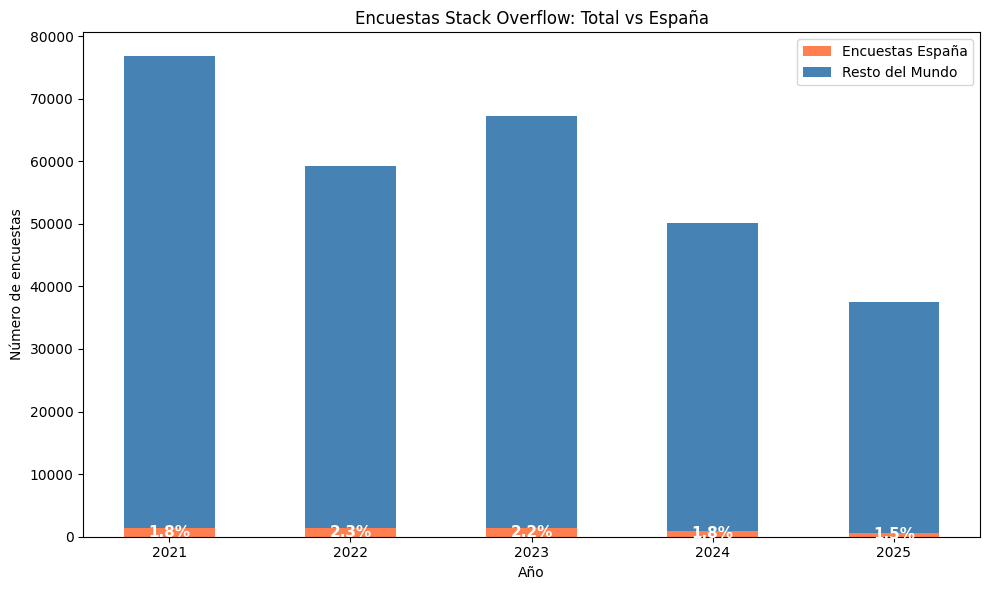

In [25]:
import matplotlib.pyplot as plt

df_plot = df_master_total.groupby('Year').size().reset_index(name='Total_Encuestas') #contamos el número de encuestas por año
df_plot_spain = df_master.groupby('Year').size().reset_index(name='Encuestas_España') #contamos el número de encuestas por año para España
df_plot = df_plot.merge(df_plot_spain, on='Year', how='left') #hacemos un merge para juntar ambos DataFrames
df_plot['Resto_Mundo'] = df_plot['Total_Encuestas'] - df_plot['Encuestas_España'] #calculamos el número de encuestas del resto del mundo
df_plot['Porcentaje_España'] = (df_plot['Encuestas_España'] / df_plot['Total_Encuestas']) * 100 #calculamos el porcentaje de encuestas de España

fig, ax = plt.subplots(figsize=(10, 6)) #creamos la figura y el eje para el gráfico
x = range(len(df_plot))
width = 0.5

# Barra de España abajo
bars_spain = ax.bar(x, df_plot['Encuestas_España'], width, label='Encuestas España', color='coral')
# Barra del resto del mundo apilada encima
bars_resto = ax.bar(x, df_plot['Resto_Mundo'], width, bottom=df_plot['Encuestas_España'], label='Resto del Mundo', color='steelblue')

# Añadir el porcentaje dentro de las barras de España
for i, (bar, pct) in enumerate(zip(bars_spain, df_plot['Porcentaje_España'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, f'{pct:.1f}%',
            ha='center', va='center', fontweight='bold', color='white', fontsize=11)

ax.set_xticks(list(x))
ax.set_xticklabels(df_plot['Year'].astype(int))
ax.set_xlabel('Año')
ax.set_ylabel('Número de encuestas')
ax.legend()
ax.set_title('Encuestas Stack Overflow: Total vs España')
plt.tight_layout()
plt.show()

En la grágica podemos ver como a partir, sobre todo, con el auge de los LLMs el numero de encuestas se ha reducido drasticamente ya que desde entonces Stack Overflow ha mostrado un enorme descenso de visualizaciones y realizacióln de nuevas consultas debido a la gente acude directamente a consultar a IA como es muestra en este grafico.

![Evolución Stack Overflow](img/nuevas-consultas-Stack-Overflow.png)

Fuente de los datos: [Stack Exchange Data Explorer](https://data.stackexchange.com/)

Se aprecia una fase de crecimiento de 2008 a 2014, una segunda fase de consolidación hasta 2022 y por último un brusco descenso desde 2022 hasta hoy, coincidiendo con la aparicion de los grandes modelos de Lenguage como ChatGPT y volviendo a los niveles de su comienzo en 2008.

Tambien se aprecia que la participación de España en esta encuesta mundial es casi insignificante.

In [26]:
# %pip install pycountry

In [32]:
import plotly.express as px
import pycountry

geo_df = df_master_total['Pais'].value_counts().reset_index()
geo_df.columns = ['Pais', 'Encuestas']

#la localización por paises "country names" va a ser deprecada por lo que comvertimos los nombres de los paises a los codigos ISO de cada país para usar "ISO-3" como locationmode
def get_iso3(country_name):
        try:
            return pycountry.countries.lookup(country_name).alpha_3  # lookup busca por nombre común/oficial, si no encuentra el país como "United States of America"
        except (LookupError, AttributeError, TypeError):
            return None

geo_df['ISO-3'] = geo_df['Pais'].apply(get_iso3)


fig = px.scatter_geo(geo_df, locations="ISO-3", locationmode="ISO-3",
                     size="Encuestas", 
                     hover_name="Pais",
                     hover_data={"ISO-3": False, "Encuestas": True},
                     color="Encuestas",
                     projection="natural earth",
                     title="Distribución geográfica de encuestados Stack Overflow")
fig.show()
#geo_df


Ahora vamos a ver la evolucion de la escusta comprando el número de columnas que tenemos para cada año, para ver si el aumento de encuestas también ha traído un aumento de información o si se ha mantenido constante.

Lo guardamos en un df para luego poder imprimirlo en un grafico de barras mostrando el número de columnas por año

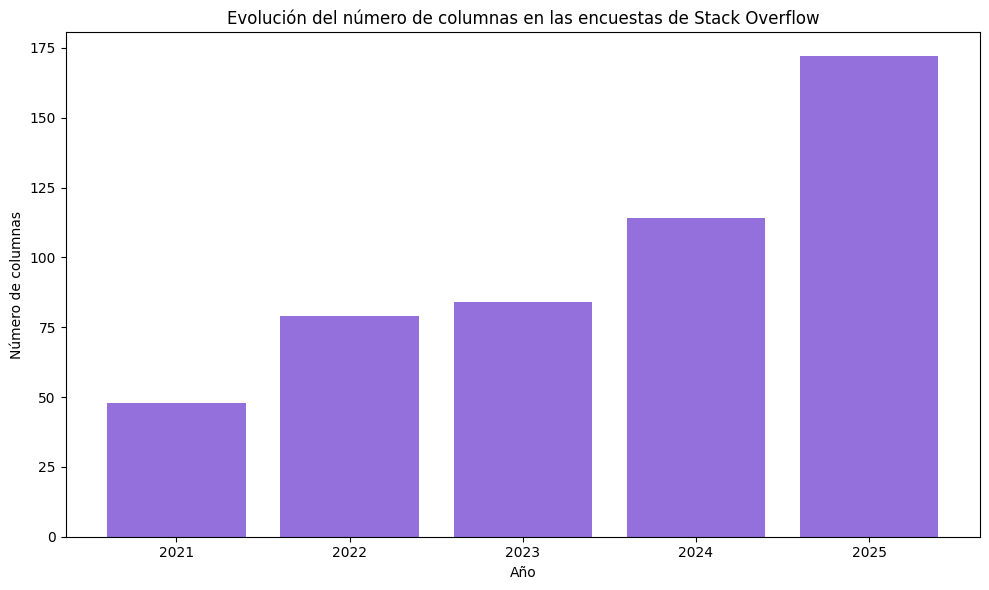

In [33]:
#creamos un DataFrame con el número de columnas de cada año para ver la evolución del número de preguntas en las encuestas a lo largo de los años   
df_columns = pd.DataFrame({
    'Año': [2021, 2022, 2023, 2024, 2025],
    'Número_Columnas': [len(df_stack_21.columns), len(df_stack_22.columns), len(df_stack_23.columns), len(df_stack_24.columns), len(df_stack_25.columns)]
})

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(df_columns['Año'], df_columns['Número_Columnas'], color='mediumpurple')
ax.set_xlabel('Año')
ax.set_ylabel('Número de columnas')
ax.set_title('Evolución del número de columnas en las encuestas de Stack Overflow')
plt.tight_layout()
plt.show()

Aquí podemos ver como la encueta se ha ido ampliando para concretar las preguntas, añadir nuevas preguntas como a partir de 2023 icormporando una sección sobre IA.

Ahora vamos a analizar la evolución de los lenguajes más populares a lo largo de los años para ver si hay tendencias claras de crecimiento o decrecimiento en su uso y deseo

En este punto ya tenemos filtrado el DataFrame con los datos de España y la dedicación, por lo que podemos analizar la evolución de los lenguajes más populares a lo largo de los años para ver si hay tendencias claras de crecimiento o decrecimiento en su uso y deseo


In [34]:
from plotly.offline import init_notebook_mode, iplot, plot

top10_items = list(used_languages.items())[:10]
pie1_list = [count for _, count in top10_items]
labels = list(used_languages.keys())[:10]


top10_items_to_learn = list(desired_languages.items())[:10]
pie2_list = [count for _, count in top10_items_to_learn]
labels2 = list(desired_languages.keys())[:10]

fig = {
    "data": [
        {
            "values": pie1_list,
            "labels": labels,
            "domain": {"x": [0, 0.45]},
            "name": "Más usados",
            "hoverinfo": "label+percent+name",
            "hole": 0.3,
            "type": "pie"
        },
        {
            "values": pie2_list,
            "labels": labels2,
            "domain": {"x": [0.55, 1]},
            "name": "Más deseados",
            "hoverinfo": "label+percent+name",
            "hole": 0.3,
            "type": "pie"
        },
    ],
    "layout": {
        "title": "Top 10 Lenguajes: Uso vs Deseo (España)",
        "annotations": [
            {"font": {"size": 16}, "showarrow": False, "text": "Más usados", "x": 0.18, "y": -0.1},
            {"font": {"size": 16}, "showarrow": False, "text": "Más deseados", "x": 0.82, "y": -0.1},
        ]
    }
}
iplot(fig)

Vemos que existe cierta correlación entre los lenguajes más usados y los más deseados, aunque también hay diferencias notables. 
Por ejemplo, Python es el cuarto lenguaje más usado y también el degundo más deseado, lo que indica una fuerte popularidad, demanda y proyección de este lenguaje.

JavaScript es el lenguaje más usado y tambien el que tiene más proyección debido al interés de los usuarios.

Por otro lado, lenguajes como Rust o Go pueden aparecer más alto en la lista de los más deseados que en la de los más usados, lo que sugiere un interés creciente en tecnologías emergentes.

Y por último lenguajes como PHP tienden a desaparecer debido a la falta de interes por parte de los usuario, a pesar de impulsar más del 75% de los sitios web conocidos, con CMS como Wordpress, Drupal o Joomla, eCommerce como Magento, WooCommerce y Prestashop o frameworks como Symfony y Laravel.

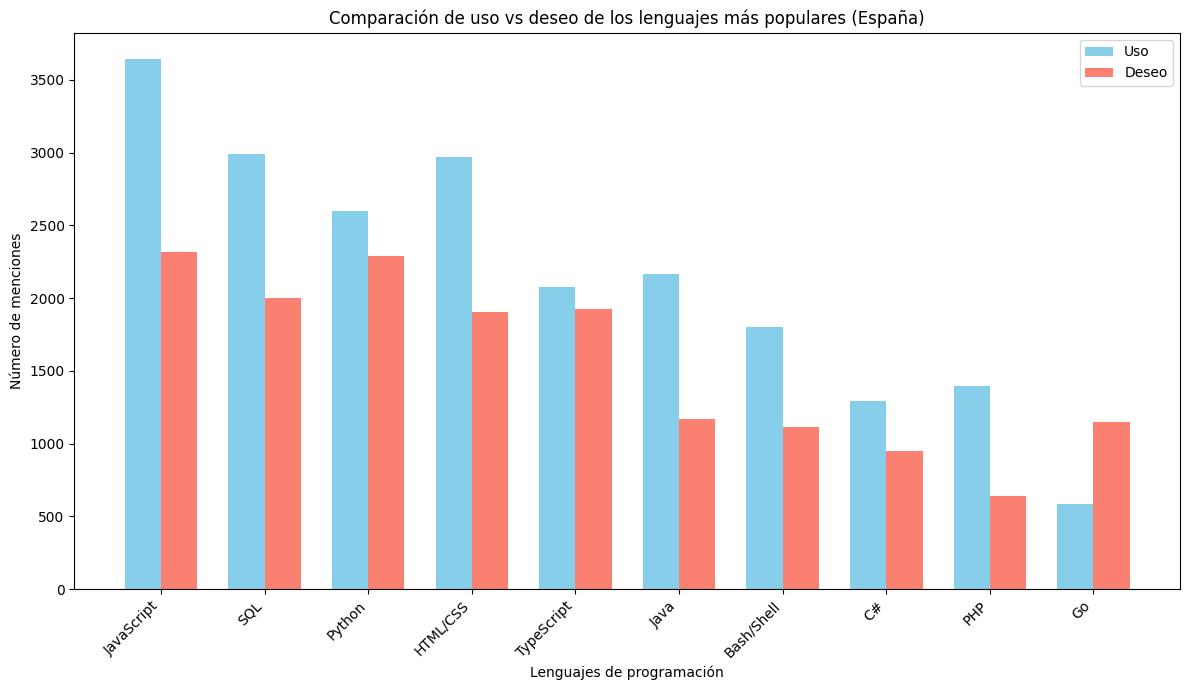

In [35]:
# ahora vamos a crear un gráfico de barras para comparar el número de menciones de los lenguajes más populares en uso y deseo
top10_populares = list(popular_languages.items())[:10]
lenguajes = [lang for lang, _ in top10_populares]
uso_counts = [used_languages[lang] for lang in lenguajes]
deseo_counts = [desired_languages[lang] for lang in lenguajes]
x = np.arange(len(lenguajes))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 7))
bars_uso = ax.bar(x - width/2, uso_counts, width, label='Uso', color='skyblue')
bars_deseo = ax.bar(x + width/2, deseo_counts, width, label='Deseo', color='salmon')
ax.set_xlabel('Lenguajes de programación')
ax.set_ylabel('Número de menciones')
ax.set_title('Comparación de uso vs deseo de los lenguajes más populares (España)')
ax.set_xticks(x)
ax.set_xticklabels(lenguajes, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
#ahora comparamos los lenguajes más populares con las tendencias de busqueda de Google Trends 
# Para eso empezaremos por comparar JavaScript uso y deseo a los largo de los años con su tendencia en Google Trends
# Convertimos Time a datetime si no lo está
def plot_language_trends(lang_name, df_master, df_trends, years):
    """Genera gráfico de evolución uso/deseo Stack Overflow vs Google Trends para un lenguaje."""
    df_trends['Time'] = pd.to_datetime(df_trends['Time'])
    
    evo_uso = [df_master[df_master['Year'] == year]['Lenguajes_uso'].fillna('').str.split(';').apply(lambda x, l=lang_name: l in x).sum() for year in years]
    evo_deseo = [df_master[df_master['Year'] == year]['Lenguajes_deseo'].fillna('').str.split(';').apply(lambda x, l=lang_name: l in x).sum() for year in years]
    
    years_dt = [pd.Timestamp(year=y, month=6, day=1) for y in years]
    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    ax1.set_xlabel('Fecha')
    ax1.set_ylabel('Menciones Stack Overflow (España)', color='blue')
    ax1.plot(years_dt, evo_uso, label=f'Uso {lang_name} (SO)', marker='o', color='blue')
    ax1.plot(years_dt, evo_deseo, label=f'Deseo {lang_name} (SO)', marker='o', color='cyan')
    ax1.tick_params(axis='y', labelcolor='blue')
    
    # Solo añadir Google Trends si el lenguaje existe en df_trends
    if lang_name in df_trends.columns:
        ax2 = ax1.twinx()
        ax2.set_ylabel('Google Trends', color='red')
        ax2.plot(df_trends['Time'], df_trends[lang_name], label='Google Trends', color='red', alpha=0.6)
        ax2.tick_params(axis='y', labelcolor='red')
    
    fig.suptitle(f'Evolución de {lang_name}: Stack Overflow vs Google Trends')
    fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
    plt.tight_layout()
    plt.show()

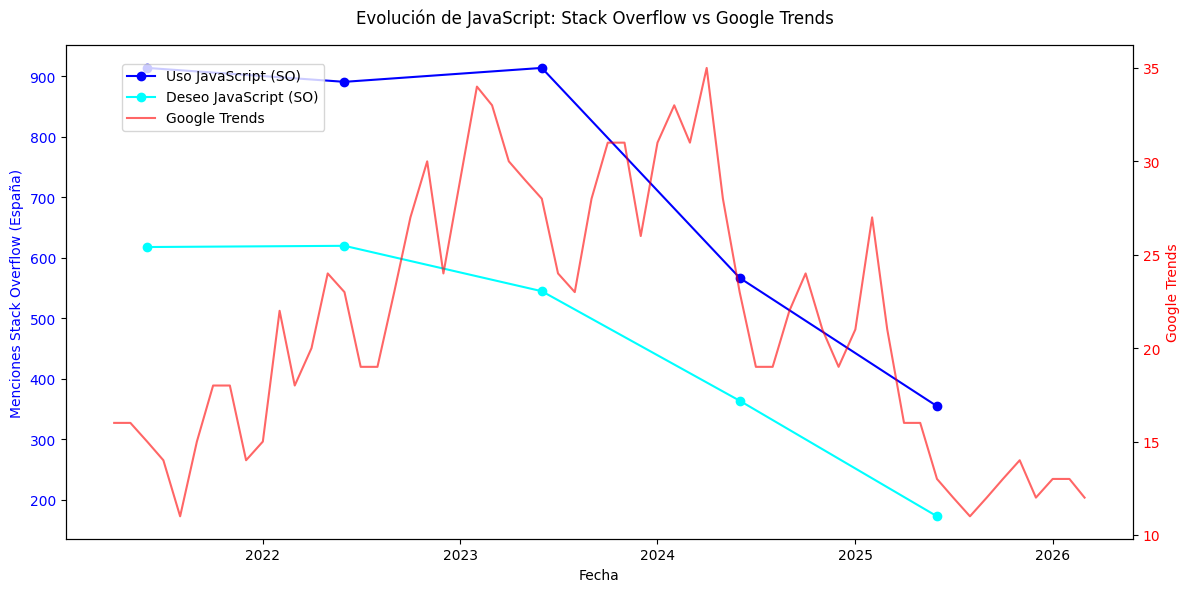

In [37]:
plot_language_trends('JavaScript', df_master, df_trends, years)


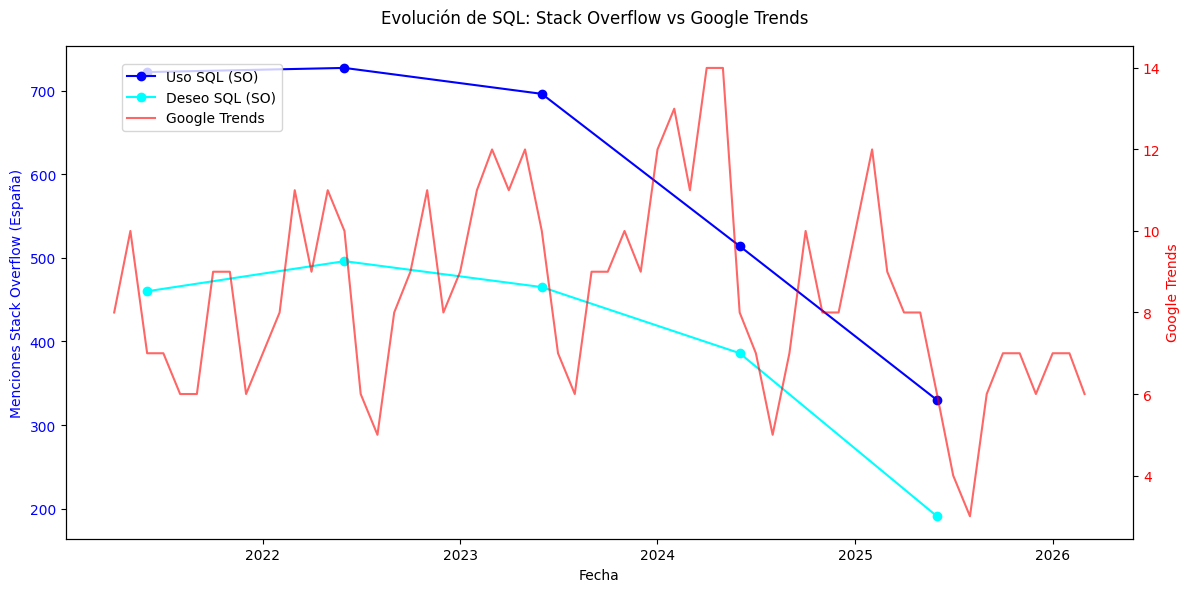

In [38]:
plot_language_trends('SQL', df_master, df_trends, years)


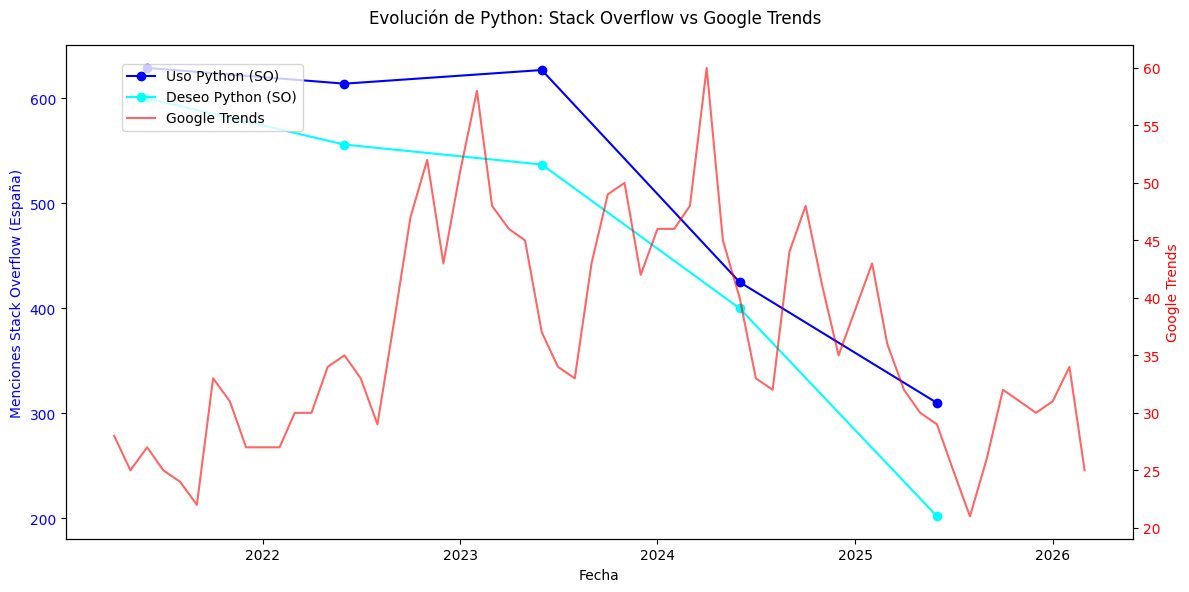

In [39]:
plot_language_trends('Python', df_master, df_trends, years)


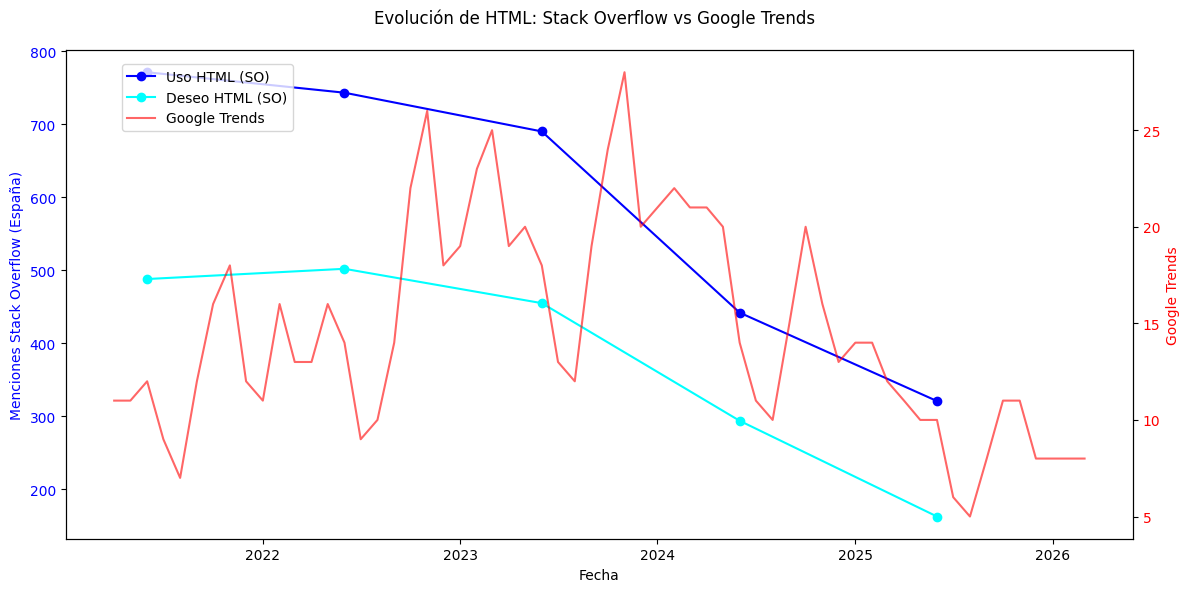

In [40]:
plot_language_trends('HTML', df_master, df_trends, years)

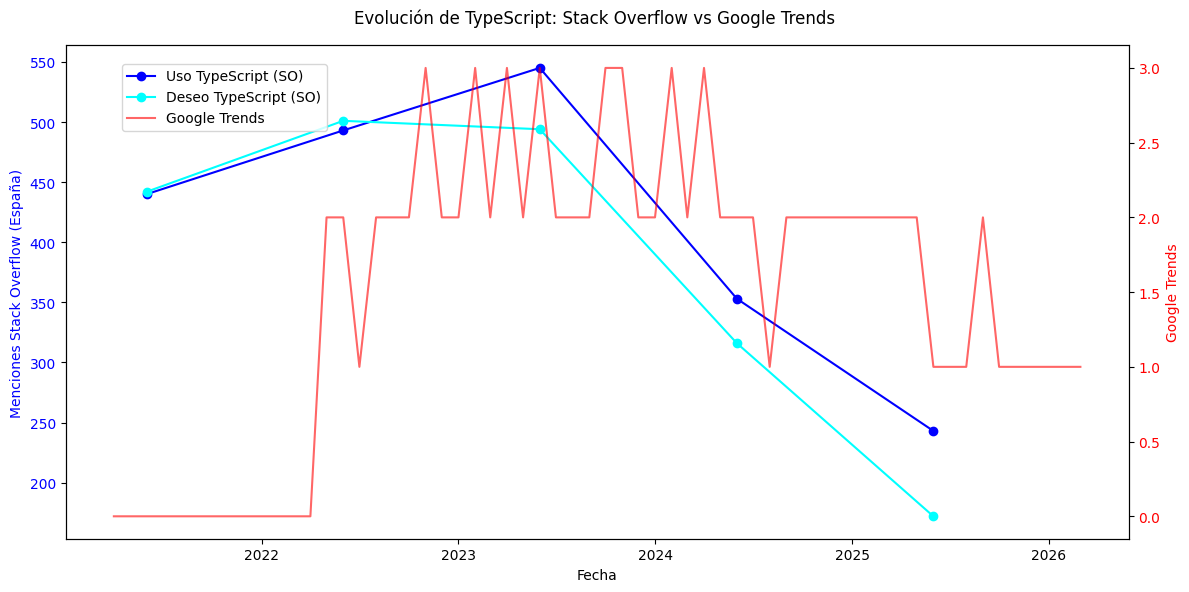

In [41]:
plot_language_trends('TypeScript', df_master, df_trends, years)

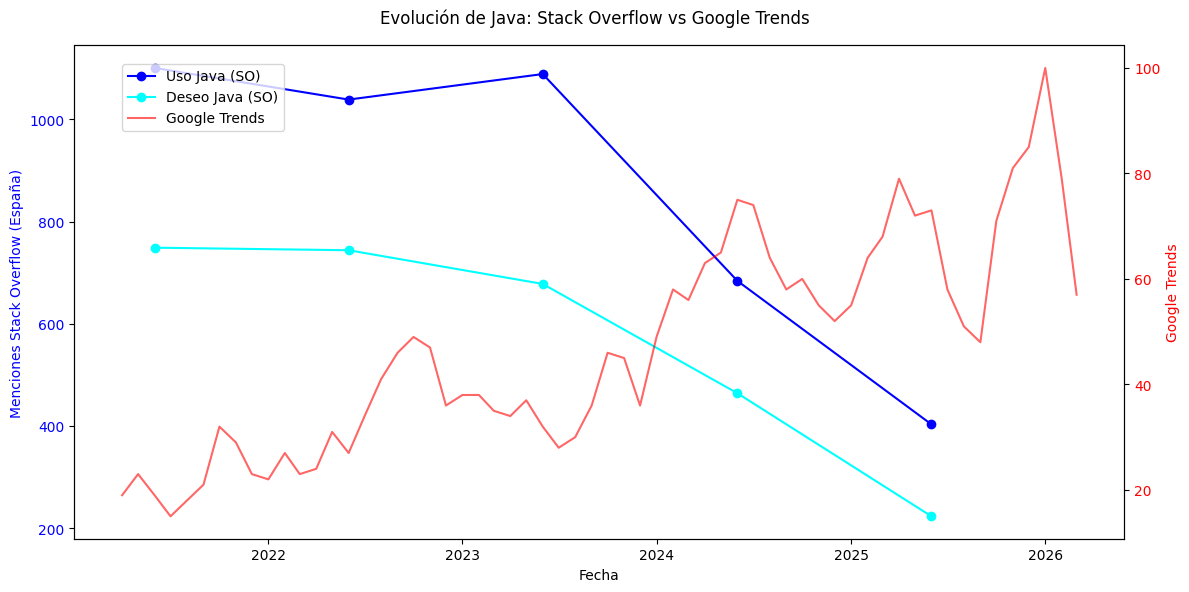

In [42]:
plot_language_trends('Java', df_master, df_trends, years)

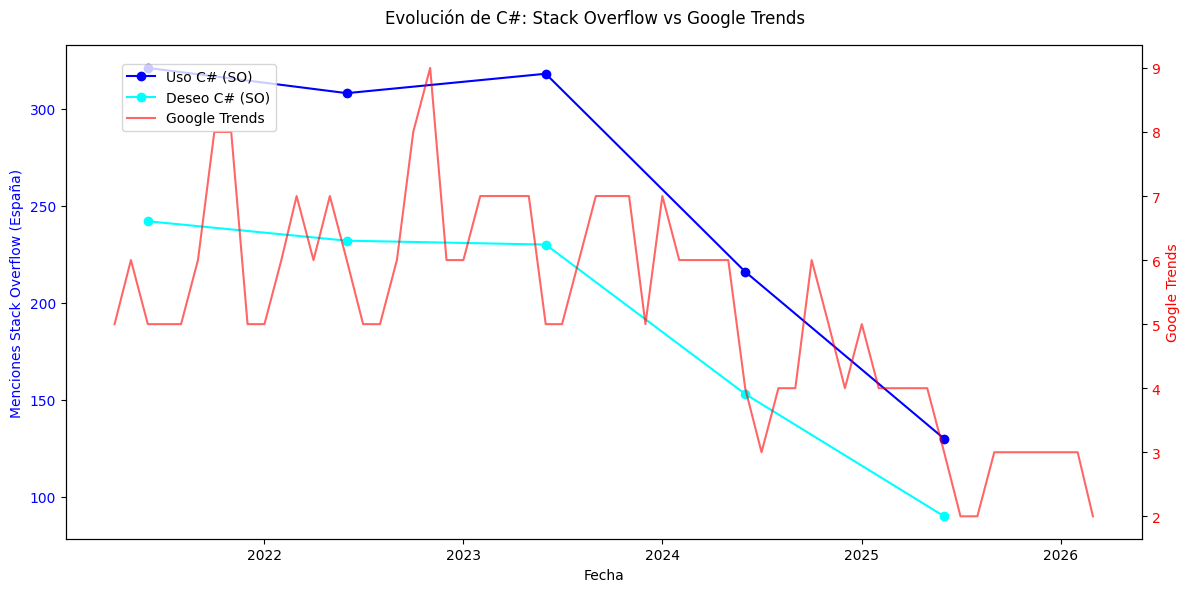

In [43]:
plot_language_trends('C#', df_master, df_trends, years)

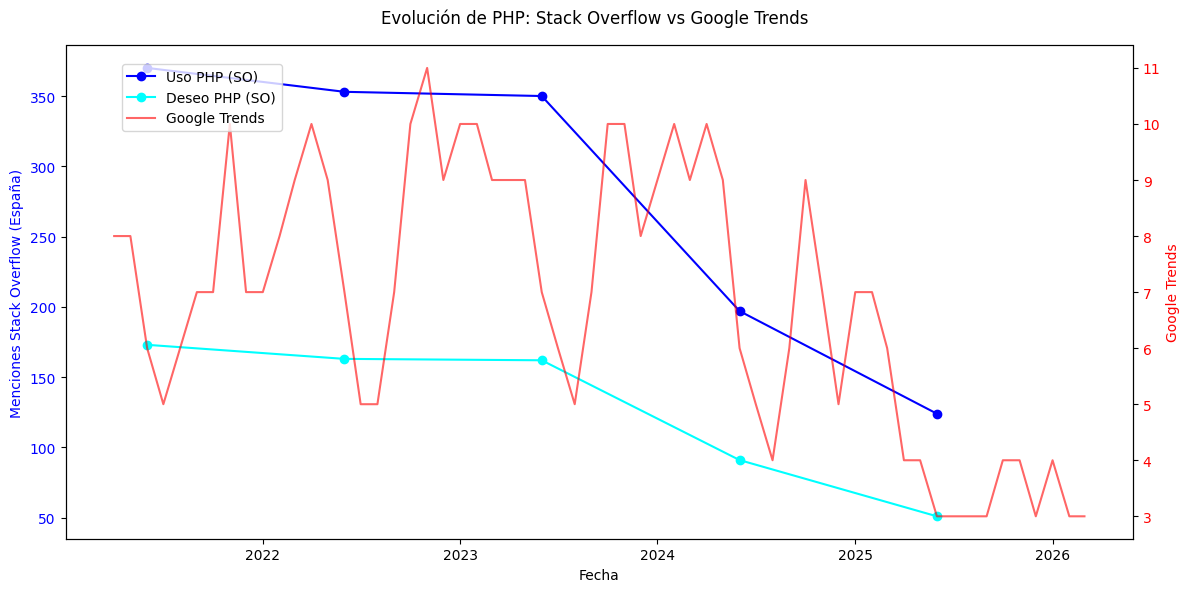

In [44]:
plot_language_trends('PHP', df_master, df_trends, years)

In [53]:
#metemos en un array unidimensional los 10 lenguajes más populares en uso pero solo el nombre del lenguaje
top_10_languages = df_popular_languages.sort_values(by='Uso', ascending=False)[:10]['Lenguaje'].values
top_10_languages

<StringArray>
['JavaScript',        'SQL',   'HTML/CSS',     'Python',       'Java',
 'TypeScript', 'Bash/Shell',        'PHP',         'C#',        'C++']
Length: 10, dtype: str

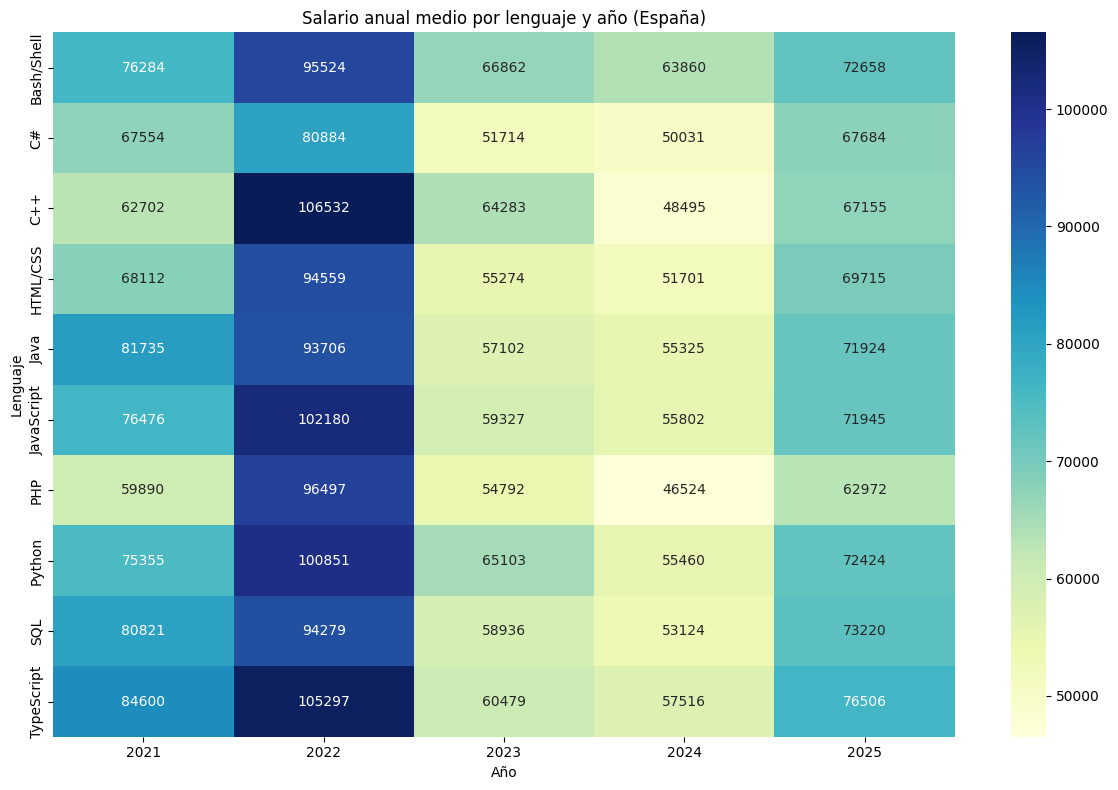

In [60]:
#vamos a crear un sns.heatmap con los lenguajes mas usados y el salario anual medio para cada lenguaje y entre los años
import seaborn as sns
#creamos un nuevo DataFrame con el salario anual medio para cada lenguaje de top_10_languages y para cada año de la lista 
#para conprobar 1º debe ver que algunao de los lenguajes de la lista top_10_languages esté en la columna de uso analizando toda la cadena de texto sepradeda por ';'
# y luego calcular el salario anual medio para cada lenguaje agupado por año
salarios_lenguajes = []
for lang in top_10_languages:
    mask = df_master['Lenguajes_uso'].fillna('').str.split(';').apply(lambda x, l=lang: l in x)
    df_lang = df_master[mask].copy()
    df_lang['Lenguajes_uso'] = lang
    salarios_lenguajes.append(df_lang[['Lenguajes_uso', 'Salario_anual', 'Year']])

df_top_10_languages = pd.concat(salarios_lenguajes, ignore_index=True).dropna(subset=['Salario_anual'])

plt.figure(figsize=(12, 8))

sns.heatmap(df_top_10_languages.pivot_table(index='Lenguajes_uso', columns='Year', values='Salario_anual', aggfunc='mean'), annot=True, fmt=".0f", cmap="YlGnBu")
plt.xlabel('Año')
plt.ylabel('Lenguaje')
plt.title('Salario anual medio por lenguaje y año (España)')
plt.tight_layout()
plt.show()



In [63]:
df_top_10_languages.head(50)


,Lenguajes_uso,Salario_anual,Year
0,JavaScript,46482.0,2021
1,JavaScript,58373.0,2021
2,JavaScript,38915.0,2021
5,JavaScript,12972.0,2021
6,JavaScript,28105.0,2021
7,JavaScript,64860.0,2021
9,JavaScript,16215.0,2021
10,JavaScript,45396.0,2021
11,JavaScript,51888.0,2021
12,JavaScript,9729.0,2021
